/tmp/ipykernel_8841/1682085294.py:3: DtypeWarning: Columns (141: ServedActiveDutyInUsArmedForces) have mixed types. Specify dtype option on import or set low_memory=False.
  nhanes=pd.read_csv("https://raw.githubusercontent.com/Psyc3000A/Data/refs/heads/main/nhanes.csv")


<Axes: >

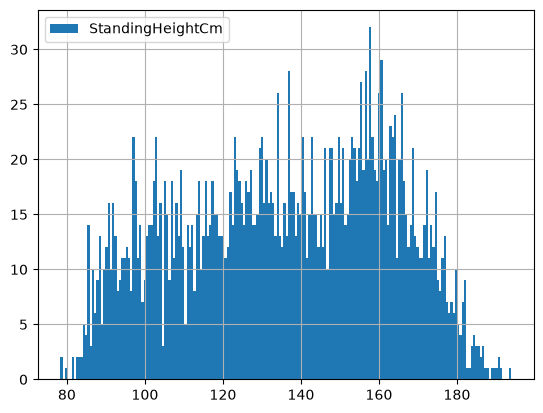

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
nhanes=pd.read_csv("https://raw.githubusercontent.com/Psyc3000A/Data/refs/heads/main/nhanes.csv")

children = nhanes[nhanes["AgeInYearsAtScreening"] < 18]
children["StandingHeightCm"].hist(bins=200, legend=True)

<Axes: >

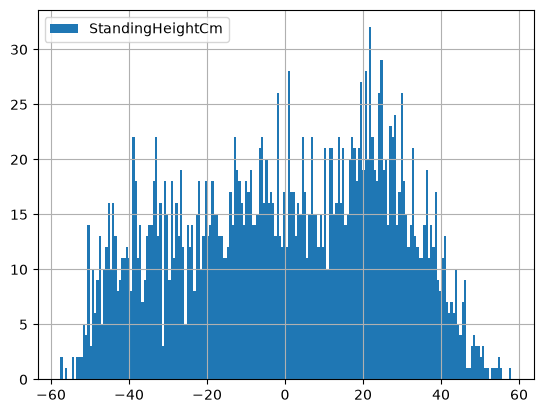

In [31]:
mean_height = children["StandingHeightCm"].mean()
# Errors
errors = children["StandingHeightCm"] - mean_height
errors.hist(bins=200, legend=True)

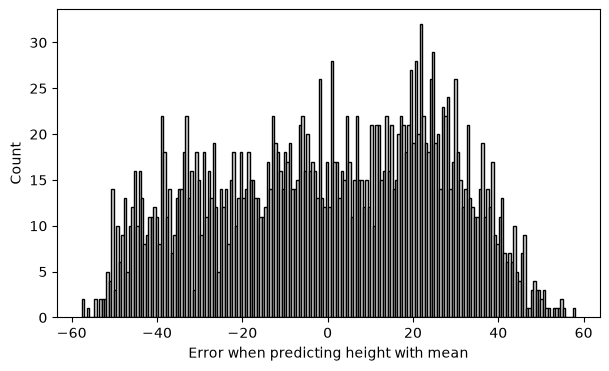

In [32]:
mean_height = children["StandingHeightCm"].mean()
# Errors
errors = children["StandingHeightCm"] - mean_height
# Plot
plt.figure(figsize=(7, 4))
plt.hist(errors, bins=200,color="lightgray", edgecolor="black")
plt.xlabel("Error when predicting height with mean")
plt.ylabel("Count")
plt.show()

/tmp/ipykernel_8841/357925539.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  children["Gender_code"] = (children["Gender"].astype(str).str.lower().isin(["male", "1"])).astype(int)


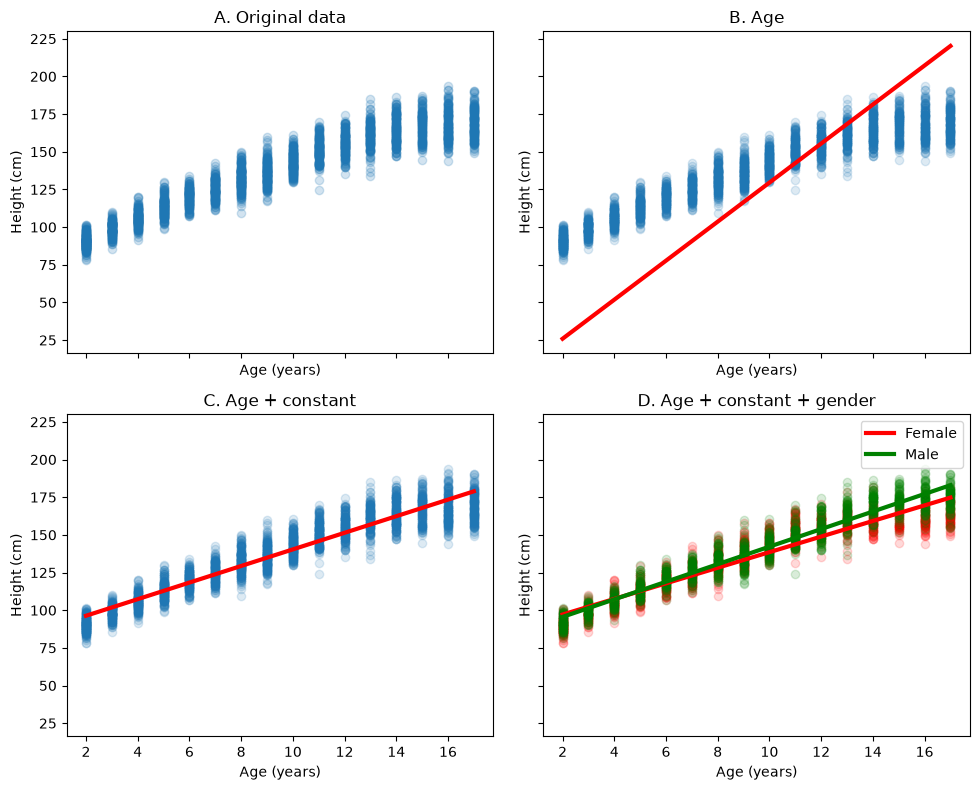

In [33]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

children["Gender_code"] = (children["Gender"].astype(str).str.lower().isin(["male", "1"])).astype(int)
children  = children[["StandingHeightCm", "AgeInYearsAtScreening", "Gender_code"]].dropna()

m_age = LinearRegression(fit_intercept=False).fit(children[["AgeInYearsAtScreening"]],children["StandingHeightCm"])
m_age_const = LinearRegression().fit(children[["AgeInYearsAtScreening"]], children["StandingHeightCm"])

m_full = LinearRegression().fit(children[["AgeInYearsAtScreening", "Gender_code"]],children["StandingHeightCm"])
children = children.sort_values("AgeInYearsAtScreening")

children["pred_age"] = m_age.predict(children[["AgeInYearsAtScreening"]])
children["pred_age_const"] = m_age_const.predict(children[["AgeInYearsAtScreening"]])
children["pred_full"] = m_full.predict(children[["AgeInYearsAtScreening", "Gender_code"]])

children["Age_Gender"] = (children["AgeInYearsAtScreening"] * children["Gender_code"])

m_interaction = LinearRegression().fit(children[["AgeInYearsAtScreening","Gender_code","Age_Gender"]],children["StandingHeightCm"])

children["pred_interaction"] = m_interaction.predict(children[["AgeInYearsAtScreening","Gender_code","Age_Gender"]])
fig, ax = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)

# A: Original data
ax[0,0].scatter(children["AgeInYearsAtScreening"], children["StandingHeightCm"], alpha=.2)
ax[0,0].set_title("A. Original data")

# B: Age only
ax[0,1].scatter(children["AgeInYearsAtScreening"], children["StandingHeightCm"], alpha=.15)
ax[0,1].plot(children["AgeInYearsAtScreening"], children["pred_age"], color="red", lw=3)
ax[0,1].set_title("B. Age")

# C: Age + constant
ax[1,0].scatter(children["AgeInYearsAtScreening"], children["StandingHeightCm"], alpha=.15)
ax[1,0].plot(children["AgeInYearsAtScreening"], children["pred_age_const"], color="red", lw=3)
ax[1,0].set_title("C. Age + constant")

# D: Age + constant + gender
for g, color, label in [(0, "red", "Female"),(1, "green", "Male")]:
    tmp = children[children["Gender_code"] == g].sort_values("AgeInYearsAtScreening")
    ax[1,1].scatter(tmp["AgeInYearsAtScreening"],tmp["StandingHeightCm"],alpha=.15,color=color)
    ax[1,1].plot(tmp["AgeInYearsAtScreening"],tmp["pred_interaction"],color=color,lw=3,label=label)
ax[1,1].legend()
ax[1,1].set_title("D. Age + constant + gender")

for a in ax.ravel():
    a.set_xlabel("Age (years)")
    a.set_ylabel("Height (cm)")
plt.tight_layout()
plt.show()

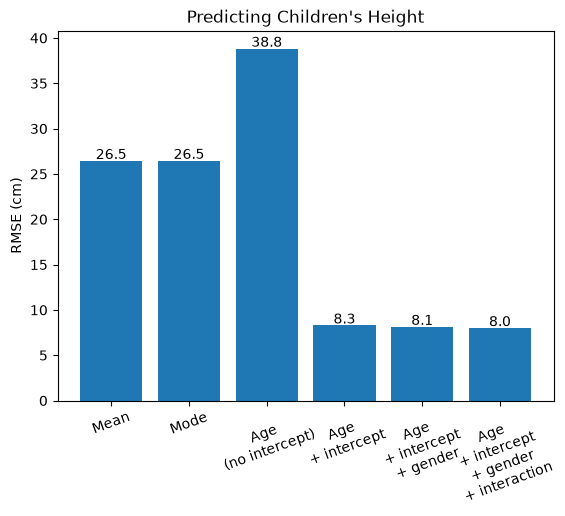

In [34]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error
rmse_age = root_mean_squared_error(    children["StandingHeightCm"],    children["pred_age"])
rmse_age_const = root_mean_squared_error(    children["StandingHeightCm"],    children["pred_age_const"])
rmse_full = root_mean_squared_error(    children["StandingHeightCm"],    children["pred_full"])
rmse_interaction = root_mean_squared_error(    children["StandingHeightCm"],    children["pred_interaction"])
# Mean model
rmse_mean = root_mean_squared_error(children["StandingHeightCm"],children["StandingHeightCm"] * 0 +children["StandingHeightCm"].mean())
# Mode model
rmse_mode = root_mean_squared_error(children["StandingHeightCm"],children["StandingHeightCm"] * 0 +children["StandingHeightCm"].mode()[0])
rmse_values = [    rmse_mean,    rmse_mode,    rmse_age,    rmse_age_const,    rmse_full,    rmse_interaction]
labels = [    "Mean",    "Mode",    "Age\n(no intercept)",    "Age\n+ intercept",    "Age\n+ intercept\n+ gender",    "Age\n+ intercept\n+ gender\n+ interaction"]
plt.bar(labels, rmse_values)
for i, v in enumerate(rmse_values):
    plt.text(i, v + 0.2, f"{v:.1f}", ha="center")
plt.ylabel("RMSE (cm)")
plt.title("Predicting Children's Height")
plt.xticks(rotation=20)
plt.show()



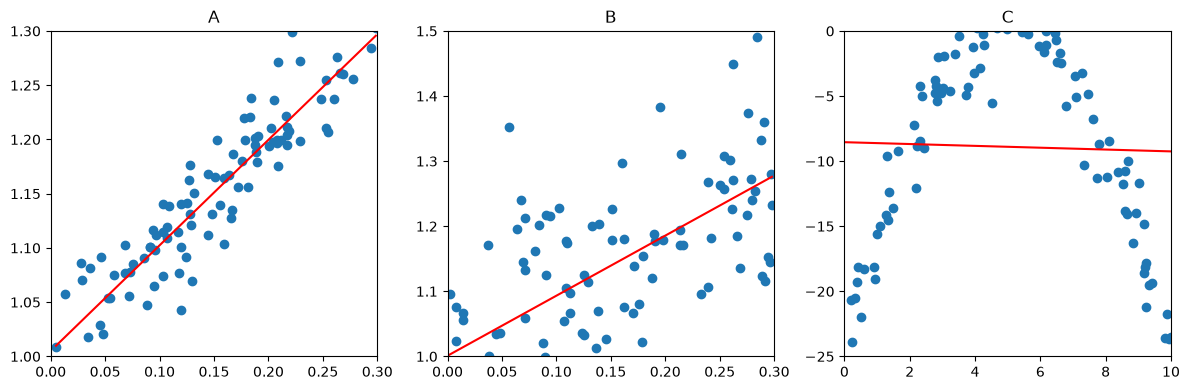

In [35]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(123)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

# A: linear, low noise
x = np.random.uniform(0, .3, 100)
y = 1 + x + np.random.normal(0, .03, 100)

# B: same relation, higher noise
xhighnoise = np.random.uniform(0, .3, 100)
yhighnoise = 1 + xhighnoise + np.random.normal(0, .10, 100)

# C: nonlinear
xnonlinear = np.random.uniform(0, 10, 100)
ynonlinear = -(xnonlinear - 5)**2 + np.random.normal(0, 2, 100)
coef = np.polyfit(x, y, 1)

# A: linear, low noise
ax[0].scatter(x, y)
ax[0].plot(np.sort(x), np.poly1d(coef)(np.sort(x)), color="red")
ax[0].set_xlim(0, .3)
ax[0].set_ylim(1.0, 1.3)
ax[0].set_title("A")


# B: same relation, higher noise
coef = np.polyfit(xhighnoise, yhighnoise, 1)
ax[1].scatter(xhighnoise, yhighnoise)
ax[1].plot(np.sort(xhighnoise), np.poly1d(coef)(np.sort(xhighnoise)), color="red")
ax[1].set_xlim(0, .3)
ax[1].set_ylim(1.0, 1.5)
ax[1].set_title("B")

#nonlinear
coef = np.polyfit(xnonlinear, ynonlinear, 1)
ax[2].scatter(xnonlinear, ynonlinear)
ax[2].plot(np.sort(xnonlinear), np.poly1d(coef)(np.sort(xnonlinear)), color="red")
ax[2].set_xlim(0, 10)
ax[2].set_ylim(-25, 0)
ax[2].set_title("C")

plt.tight_layout()
plt.show()

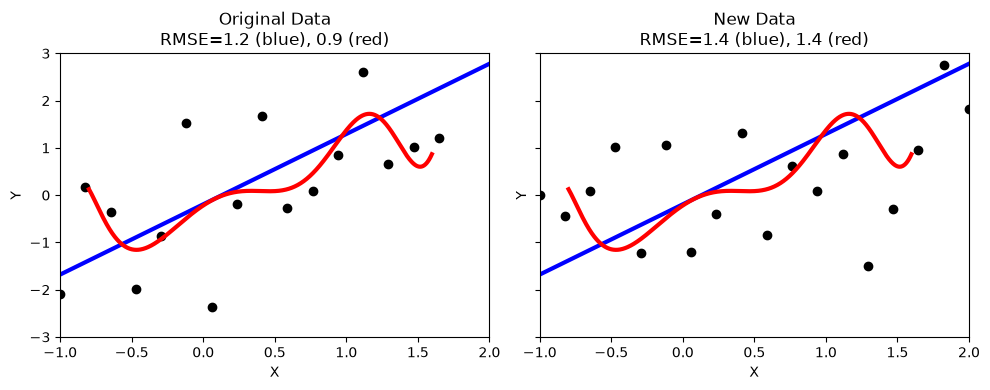

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

np.random.seed(123)
# Data
n = 18
x_train = np.linspace(-1, 2, n)
y_train = x_train + np.random.normal(0, 1.0, n)
x_test = np.linspace(-1, 2, n)
y_test = x_test + np.random.normal(0, 1.0, n)
# Models
lin = LinearRegression()
lin.fit(x_train.reshape(-1, 1), y_train)
poly = make_pipeline(    PolynomialFeatures(14),    LinearRegression())
poly.fit(x_train.reshape(-1, 1), y_train)
# Predictions
x_grid = np.linspace(-1, 2, 1000)
lin_grid = lin.predict(x_grid.reshape(-1, 1))
poly_grid = poly.predict(x_grid.reshape(-1, 1))
# Hide first and last wiggle
mask = (x_grid >= -0.8) & (x_grid <= 1.6)
# RMSE
rmse_lin_train = np.sqrt(    mean_squared_error(        y_train,        lin.predict(x_train.reshape(-1, 1))    ))
rmse_poly_train = np.sqrt(    mean_squared_error(        y_train,        poly.predict(x_train.reshape(-1, 1))    ))
rmse_lin_test = np.sqrt(    mean_squared_error(        y_test,        lin.predict(x_test.reshape(-1, 1))    ))
rmse_poly_test = np.sqrt(    mean_squared_error(        y_test,        poly.predict(x_test.reshape(-1, 1))    ))
# Plot
fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
# Original data
ax[0].scatter(x_train, y_train, color="black")
ax[0].plot(x_grid, lin_grid, color="blue", lw=3)
ax[0].plot(x_grid[mask], poly_grid[mask], color="red", lw=3)
ax[0].set_title(    f"Original Data\nRMSE={rmse_lin_train:.1f} (blue), "    f"{rmse_poly_train:.1f} (red)")
# New data
ax[1].scatter(x_test, y_test, color="black")
ax[1].plot(x_grid, lin_grid, color="blue", lw=3)
ax[1].plot(x_grid[mask], poly_grid[mask], color="red", lw=3)
ax[1].set_title(    f"New Data\nRMSE={rmse_lin_test:.1f} (blue), "    f"{rmse_poly_test:.1f} (red)")

for a in ax:
    a.set_xlim(-1, 2)
    a.set_ylim(-3, 3)
    a.set_xlabel("X")
    a.set_ylabel("Y")
plt.tight_layout()
plt.show()

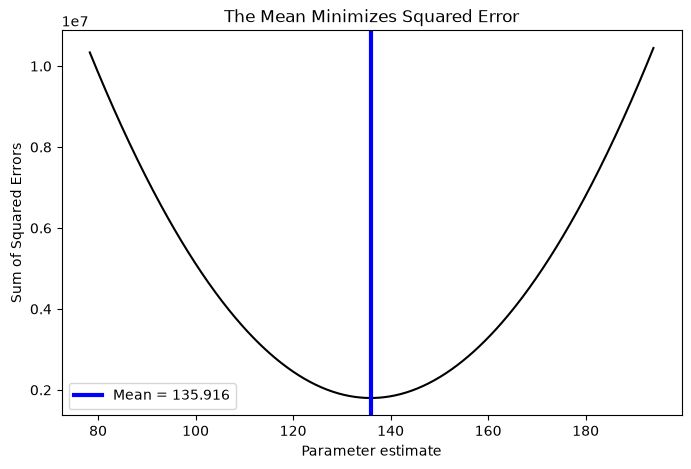

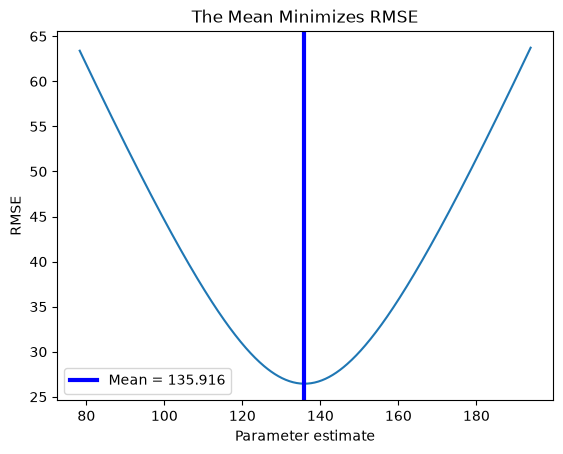

In [37]:
import numpy as np
import matplotlib.pyplot as plt
# Children only
heights = children["StandingHeightCm"]
# Mean height
mean_height = heights.mean()
# Candidate values
x = np.linspace(    heights.min(),    heights.max(),    500)
# Sum of squared errors for each candidate
sse = [    np.sum((heights - value)**2)    for value in x]
rmse = [    np.sqrt(np.mean((heights - value)**2))    for value in x]
# Plot
plt.figure(figsize=(8, 5))
plt.plot(x, sse, color="black")
plt.axvline(    mean_height,    color="blue",    lw=3,    label=f"Mean = {mean_height:.3f}")
plt.xlabel("Parameter estimate")
plt.ylabel("Sum of Squared Errors")
#plt.ticklabel_format(style="plain", axis="y")
plt.title("The Mean Minimizes Squared Error")
plt.legend()
plt.show()

plt.plot(x, rmse)
plt.axvline(    mean_height,    color="blue",    lw=3,    label=f"Mean = {mean_height:.3f}")

plt.ylabel("RMSE")
plt.xlabel("Parameter estimate")
plt.title("The Mean Minimizes RMSE")
plt.legend()
plt.show()

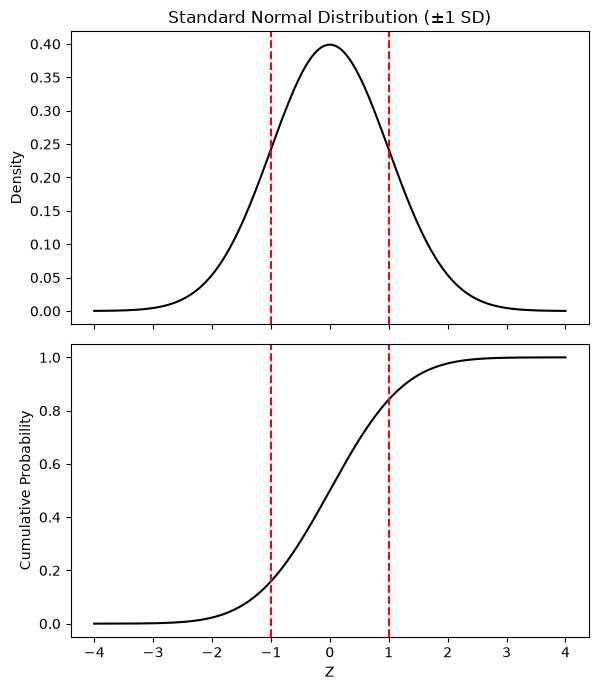

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

x = np.linspace(-4, 4, 1000)

pdf = norm.pdf(x, 0, 1)
cdf = norm.cdf(x, 0, 1)

fig, ax = plt.subplots(2, 1, figsize=(6, 7), sharex=True)

# Density
ax[0].plot(x, pdf, color="black")
ax[0].axvline(-1, color="red", linestyle="--")
ax[0].axvline(1, color="red", linestyle="--")
ax[0].set_ylabel("Density")
ax[0].set_title("Standard Normal Distribution (±1 SD)")

# CDF
ax[1].plot(x, cdf, color="black")
ax[1].axvline(-1, color="red", linestyle="--")
ax[1].axvline(1, color="red", linestyle="--")
ax[1].set_xlabel("Z")
ax[1].set_ylabel("Cumulative Probability")

plt.tight_layout()
plt.show()

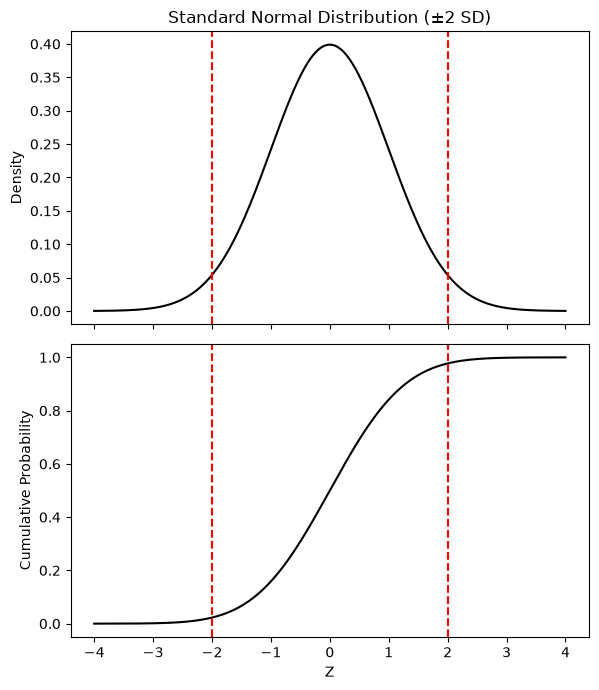

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

x = np.linspace(-4, 4, 1000)

pdf = norm.pdf(x, 0, 1)
cdf = norm.cdf(x, 0, 1)

fig, ax = plt.subplots(2, 1, figsize=(6, 7), sharex=True)

# Density
ax[0].plot(x, pdf, color="black")
ax[0].axvline(-2, color="red", linestyle="--")
ax[0].axvline(2, color="red", linestyle="--")
ax[0].set_ylabel("Density")
ax[0].set_title("Standard Normal Distribution (±2 SD)")

# CDF
ax[1].plot(x, cdf, color="black")
ax[1].axvline(-2, color="red", linestyle="--")
ax[1].axvline(2, color="red", linestyle="--")
ax[1].set_xlabel("Z")
ax[1].set_ylabel("Cumulative Probability")

plt.tight_layout()
plt.show()

using z-score

<Axes: >

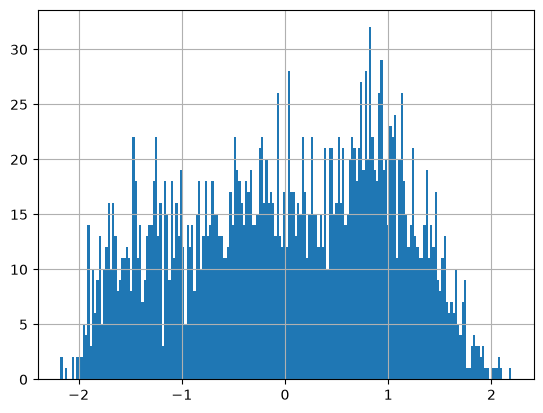

In [40]:
mean_height = children["StandingHeightCm"].mean()
std_height = children["StandingHeightCm"].std()

z_errors = (children["StandingHeightCm"] - mean_height) / std_height
z_errors.hist(bins=200)


In [41]:
# NHANES-style without excluding missing/invalid values

#df["StandingHeightCm"].describe()
children["AgeInYearsAtScreening"].describe()

count    2572.000000
mean        9.190513
std         4.563338
min         2.000000
25%         5.000000
50%         9.000000
75%        13.000000
max        17.000000
Name: AgeInYearsAtScreening, dtype: float64

In [42]:
# NHANES-style missing codes
for col in ["StandingHeightCm", "AgeInYearsAtScreening"]:
    children[col] = children[col].replace([7, 9, 77, 99, 777, 999, 7777, 9999], np.nan)
#df["StandingHeightCm"].describe()
children["AgeInYearsAtScreening"].describe()

count    2229.000000
mean        9.357111
std         4.865135
min         2.000000
25%         5.000000
50%        10.000000
75%        14.000000
max        17.000000
Name: AgeInYearsAtScreening, dtype: float64

<Axes: xlabel='StandingHeightCm', ylabel='BodyMassIndexKgm2'>

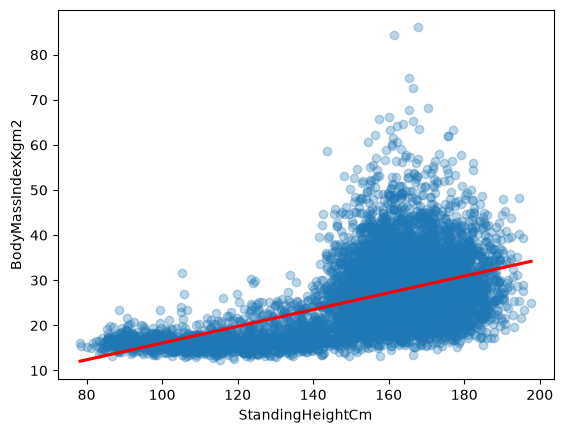

In [61]:
import seaborn as sns
import pingouin as pg

pg.linear_regression(nhanes["StandingHeightCm"], nhanes["BodyMassIndexKgm2"],remove_na=True)
sns.regplot(data=nhanes,x="StandingHeightCm", y="BodyMassIndexKgm2",scatter_kws={"color": "C0", "alpha": 0.3},line_kws={"color": "red"})
#plt.show()

In [44]:
import pandas as pd
datafile=pd.read_csv ("https://raw.githubusercontent.com/Psyc3000A/Data/refs/heads/main/sleep.csv")

pd.set_option('display.max_columns', None)
#pd.set_option('display.max_rows', None)
#pd.set_option('display.max_colwidth', None)

#datafile.groupby('group')['extra'].describe()

datafile.groupby('group').describe()

A                                                extra        \
      count  mean      std   min    25%   50%    75%   max count  mean   
group                                                                    
1      10.0   5.5  3.02765   1.0   3.25   5.5   7.75  10.0  10.0  0.75   
2      10.0  15.5  3.02765  11.0  13.25  15.5  17.75  20.0  10.0  2.33   

                                                ID                           \
            std  min    25%   50%   75%  max count mean      std  min   25%   
group                                                                         
1      1.789010 -1.6 -0.175  0.35  1.70  3.7  10.0  5.5  3.02765  1.0  3.25   
2      2.002249 -0.1  0.875  1.75  4.15  5.5  10.0  5.5  3.02765  1.0  3.25   

                        
       50%   75%   max  
group                   
1      5.5  7.75  10.0  
2      5.5  7.75  10.0

<Axes: ylabel='Density'>

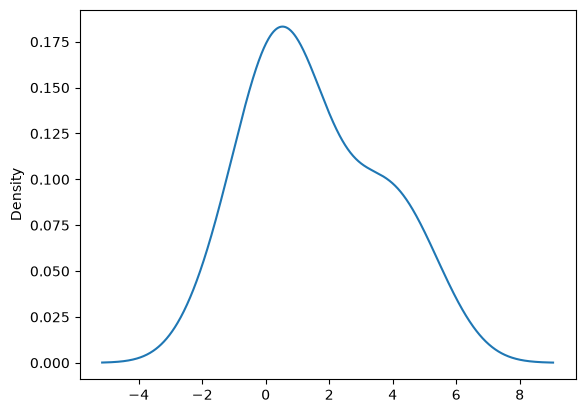

In [45]:
datafile["extra"].plot(kind="density")


group
1    Axes(0.125,0.11;0.775x0.77)
2    Axes(0.125,0.11;0.775x0.77)
Name: extra, dtype: object

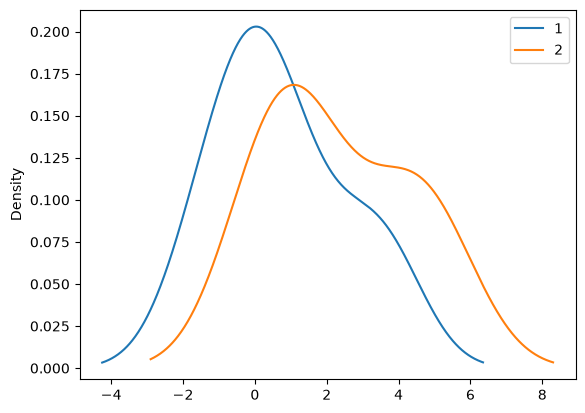

In [46]:
datafile.groupby("group")["extra"].plot(kind="density", legend=True)


In [47]:
datafile.groupby("group")["extra"].agg(["count", "mean", "std", "skew"])

,count,mean,std,skew
group,,,,
1,10,0.75,1.789010,0.580921
2,10,2.33,2.002249,0.385806


<Axes: >

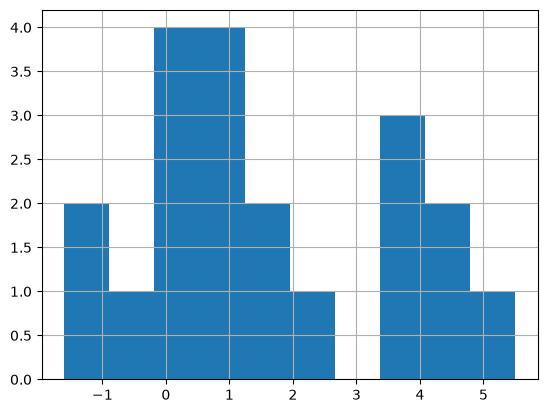

In [48]:
datafile["extra"].hist() #;

<Axes: ylabel='Density'>

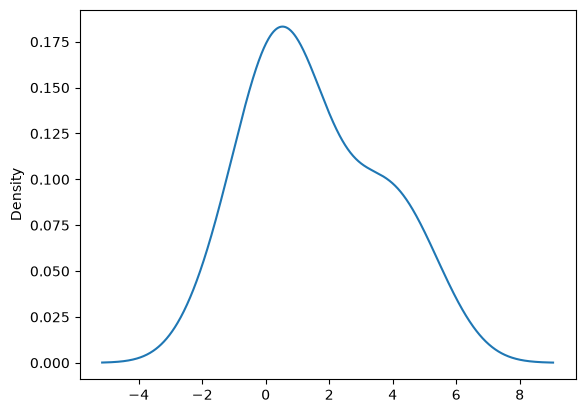

In [49]:
datafile["extra"].plot(kind="density")

<Axes: >

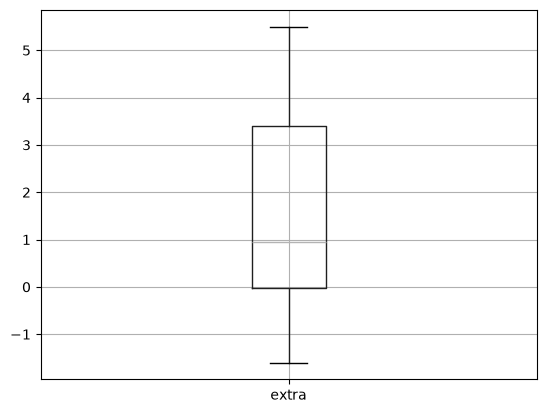

In [50]:
datafile.boxplot(column="extra")

<Axes: ylabel='Frequency'>

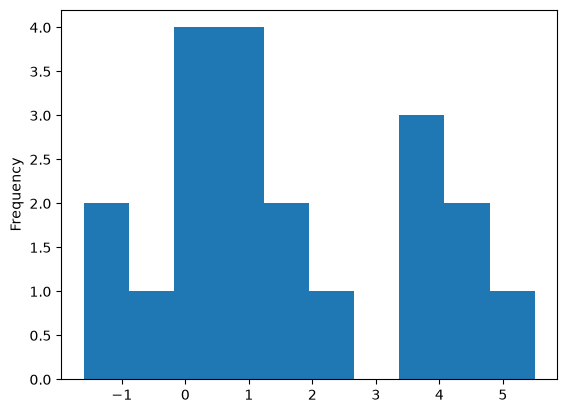

In [51]:
# Histogram
datafile["extra"].plot(kind="hist")


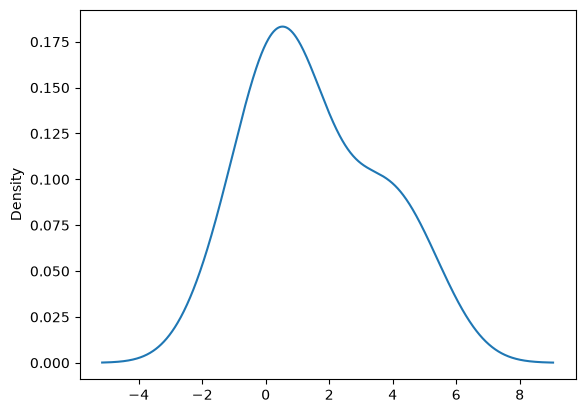

In [52]:
# Density curve
datafile["extra"].plot.kde();


<Axes: >

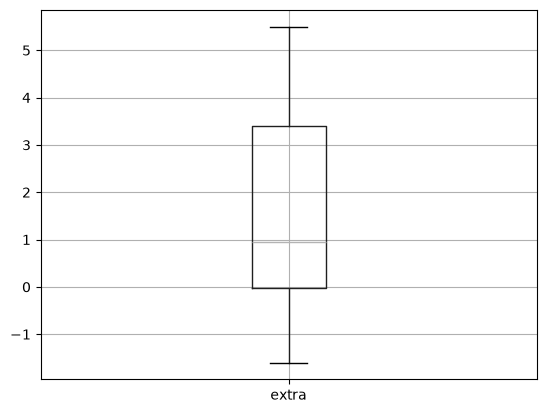

In [53]:
# Boxplot
datafile.boxplot(column="extra")

<Axes: >

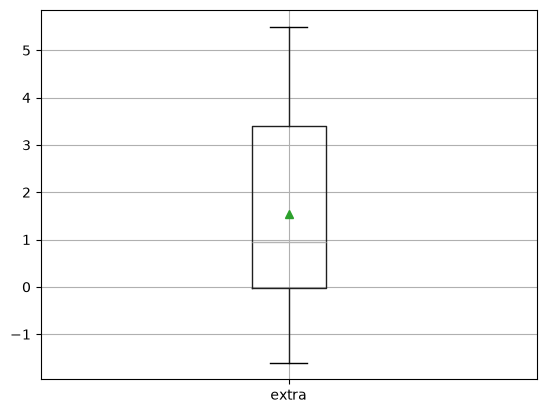

In [54]:
datafile.boxplot(column="extra", showmeans=True)


<Axes: title={'center': 'extra'}, xlabel='group'>

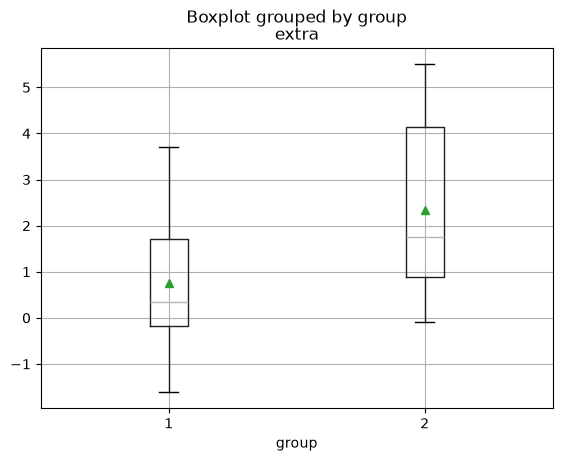

In [55]:
datafile.boxplot(column="extra", by="group", showmeans=True)
#plt.show()